In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload your image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving virat.webp to virat.webp


Exercise 1: Color Image Manipulation

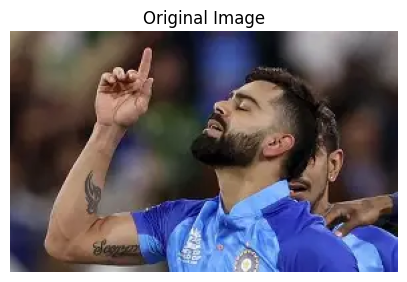

In [3]:
# Load color image
image = Image.open(filename)
plt.figure(figsize=(5,5))
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')
plt.show()

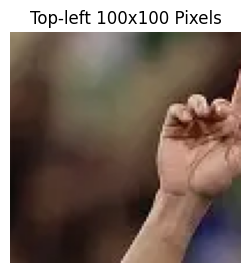

In [4]:
# Convert image to NumPy array
img_array = np.array(image)

# Extract top-left 100x100 pixels
top_left = img_array[:100, :100]
plt.figure(figsize=(3,3))
plt.title("Top-left 100x100 Pixels")
plt.imshow(top_left)
plt.axis('off')
plt.show()



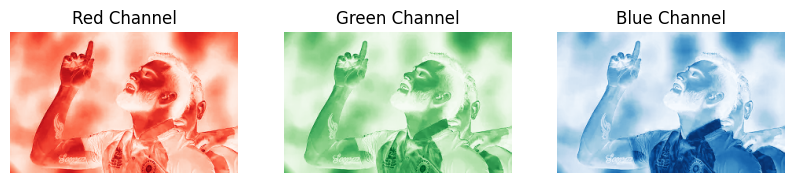

In [5]:
# Separate R, G, B channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.title("Red Channel")
plt.imshow(R, cmap='Reds')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Green Channel")
plt.imshow(G, cmap='Greens')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Blue Channel")
plt.imshow(B, cmap='Blues')
plt.axis('off')
plt.show()


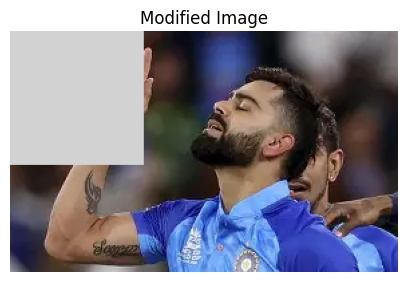

In [6]:
# Modify top-left 100x100 pixels to value 210 (light gray)
img_modified = img_array.copy()
img_modified[:100, :100] = 210
plt.figure(figsize=(5,5))
plt.title("Modified Image")
plt.imshow(img_modified)
plt.axis('off')
plt.show()

Exercise 2: Grayscale Image Processing

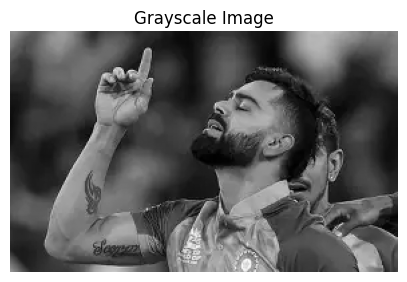

In [7]:
# Load grayscale image
gray_image = Image.open(filename).convert('L')
gray_array = np.array(gray_image)

plt.figure(figsize=(5,5))
plt.title("Grayscale Image")
plt.imshow(gray_array, cmap='gray')
plt.axis('off')
plt.show()

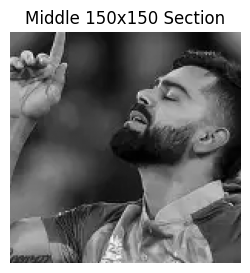

In [8]:
# Extract middle 150x150 section
h, w = gray_array.shape
mid_section = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]
plt.figure(figsize=(3,3))
plt.title("Middle 150x150 Section")
plt.imshow(mid_section, cmap='gray')
plt.axis('off')
plt.show()

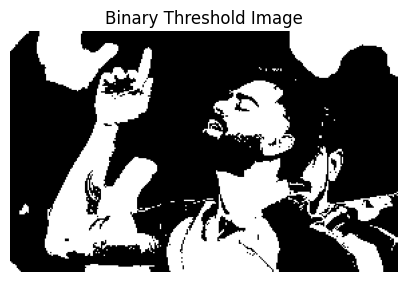

In [9]:
# Apply threshold to create binary image
threshold_array = np.where(gray_array < 100, 0, 255)
plt.figure(figsize=(5,5))
plt.title("Binary Threshold Image")
plt.imshow(threshold_array, cmap='gray')
plt.axis('off')
plt.show()

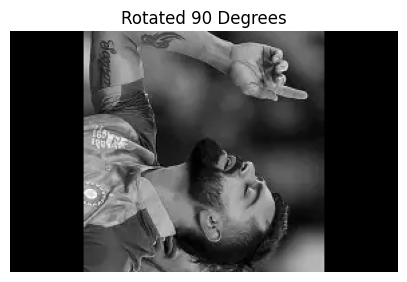

In [10]:
# Rotate 90 degrees clockwise
rotated_image = gray_image.rotate(-90)
plt.figure(figsize=(5,5))
plt.title("Rotated 90 Degrees")
plt.imshow(rotated_image, cmap='gray')
plt.axis('off')
plt.show()

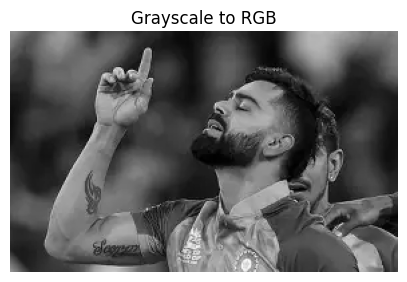

In [11]:
# Convert grayscale to RGB
gray_rgb = np.stack([gray_array]*3, axis=-1)
plt.figure(figsize=(5,5))
plt.title("Grayscale to RGB")
plt.imshow(gray_rgb)
plt.axis('off')
plt.show()

Exercise 3: PCA Image Compression

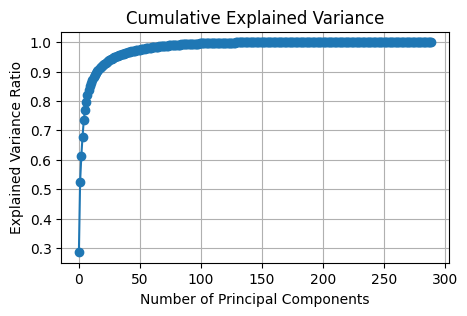

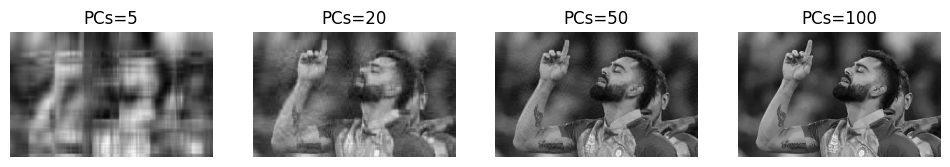

In [12]:
# ===== Exercise 3: PCA Image Compression =====

# Convert grayscale image to float
img_data = np.array(gray_image, dtype=float)

# Center data
X = img_data
X_centered = X - np.mean(X, axis=0)

# Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# Sort eigenvalues descending
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

# Cumulative explained variance
explained_variance = np.cumsum(eig_vals) / np.sum(eig_vals)
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(explained_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid()
plt.show()

# Function to reconstruct image using top k PCs
def reconstruct_image(X_centered, eig_vecs, k):
    top_k_eigvecs = eig_vecs[:, :k]
    X_reduced = np.dot(X_centered, top_k_eigvecs)
    X_reconstructed = np.dot(X_reduced, top_k_eigvecs.T) + np.mean(X, axis=0)
    return X_reconstructed

# Experiment with different k values
k_values = [5, 20, 50, 100]
plt.figure(figsize=(12,3))
for i, k in enumerate(k_values):
    rec = reconstruct_image(X_centered, eig_vecs, k)
    plt.subplot(1,4,i+1)
    plt.imshow(rec, cmap='gray')
    plt.title(f"PCs={k}")
    plt.axis('off')
plt.show()